In [1]:
import json
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import copy

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
CLASS_NAMES = ["Human", "AI"]
FOLDS = ["GPT", "CLAUDE", "GEMINI"]

# **Functions**

In [2]:
def plot_dual_curve(x_vals, train_loss, val_loss, train_acc, val_acc, x_label, model_name):
    fig, ax1 = plt.subplots(figsize=(9, 6))

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Loss")
    line1 = ax1.plot(x_vals, train_loss, color="tab:red", marker="o", label="Train Loss")
    line2 = ax1.plot(x_vals, val_loss, color="tab:orange", marker="o", linestyle="--", label="Val Loss")
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy")
    line3 = ax2.plot(x_vals, train_acc, color="tab:blue", marker="s", label="Train Accuracy")
    line4 = ax2.plot(x_vals, val_acc, color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
    ax2.tick_params(axis="y")

    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="center right")

    plt.title(f"Training/Validation Loss & Accuracy - {model_name}")
    fig.tight_layout()
    plt.show()

In [3]:
def show_examples(y_true, y_pred, texts, model_name, max_per_group=3):
    examples = {
        ("correct", 0): [], ("correct", 1): [],
        ("incorrect", 0): [], ("incorrect", 1): [],
    }
    class_names_map = {0: "Human", 1: "AI"}

    for i in range(len(y_true)):
        true_label = int(y_true[i])
        pred_label = int(y_pred[i])
        is_correct = (true_label == pred_label)
        key = ("correct" if is_correct else "incorrect", true_label)
        if len(examples[key]) < max_per_group:
            examples[key].append(texts[i])

    print(f"\n{'#'*70}\nExample - {model_name}\n{'#'*70}")
    for (status, label), txts in examples.items():
        print(f"\n{'='*60}")
        print(f"{status.upper()} - class: {class_names_map[label]} ({len(txts)} example)")
        print('='*60)
        for j, text in enumerate(txts, 1):
            print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")

In [4]:
def evaluate_and_report(model, model_name, X_val_vec, y_val, val_texts, is_keras=False, threshold=0.5):
    if is_keras:
        y_proba = model.predict(X_val_vec).flatten()
        y_pred = (y_proba > threshold).astype(int)
    else:
        y_pred = model.predict(X_val_vec)

    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

    conf_mat = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_mat, annot=True, fmt="d", cmap="BuGn",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    show_examples(y_val, y_pred, val_texts, model_name)
    return y_pred

In [5]:
def export_classic_model(model, filename):
    joblib.dump(model, filename)
    print(f"Model saved: {filename}")

def train_with_early_stopping(model, X_train_vec, y_train, X_val_vec, y_val, classes,
                               indices, loss_fn, max_epochs=100, patience=5, model_name=""):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = np.inf
    best_model = None
    epochs_without_improvement = 0
    epoch = 0

    while epoch < max_epochs:
        rng.shuffle(indices)
        model.partial_fit(X_train_vec[indices], y_train[indices], classes=classes)
        epoch += 1

        train_loss = loss_fn(model, X_train_vec, y_train)
        val_loss = loss_fn(model, X_val_vec, y_val)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(accuracy_score(y_train, model.predict(X_train_vec)))
        val_accs.append(accuracy_score(y_val, model.predict(X_val_vec)))

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch} "
                  f"(val loss has not improved for {patience} epochs)")
            break

    if best_model is None:
        best_model = model

    return best_model, train_losses, val_losses, train_accs, val_accs


results_summary = {}

def record_results(model_name, y_val, y_pred):
    report = classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
    results_summary[model_name] = {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
    }

# **FOLD 1 - GPT**

In [6]:
import json

with open("train_GPT.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_GPT.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [7]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [8]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label AI_used  chunk_no  \
0  Din această pricină, calculul offline al tabel...      0    none         9   
1  (1970), Pentru o teorie a instruirii, EDP, abo...      0    none        17   
2  Acest fapt ne conduce la ipoteza că • produc m...      0    none         8   
3  Întâi, vom face o scurtă trecere prin fundamen...      0    none         1   
4  Apoi, abilitățile de comunicare ale unei echip...      0    none         4   

   source                                         source_url  \
0     128  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...   
1     144  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
2      20  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
3     158  https://rochi.utcluj.ro/rrioc/articole/RRIOC-6...   
4      61  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...   

   year_of_publication  
0                 2011  
1                 2012  
2                 2008  
3    

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
classes = np.unique(y_train)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)

Train TF-IDF shape: (4335, 20000)
Val TF-IDF shape: (1785, 20000)


## **Logistic Regression**

[Logistic Regression - Fold 1 GPT] Early stopping at epoch 9 (val loss has not improved for 5 epochs)


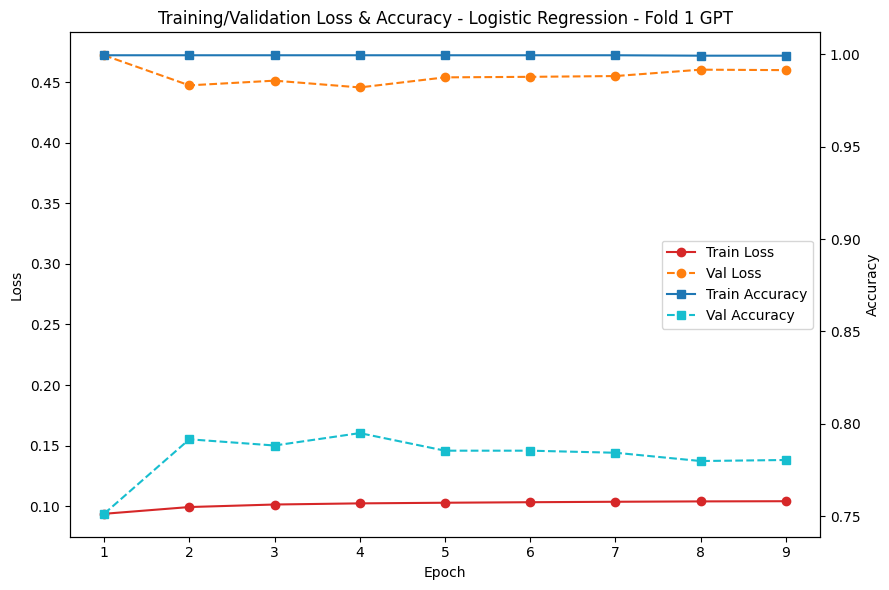

In [10]:
indices = np.arange(X_train_tfidf.shape[0])

def logreg_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

logreg_model, lr_train_losses, lr_val_losses, lr_train_accs, lr_val_accs = train_with_early_stopping(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=logreg_log_loss, max_epochs=100, patience=5, model_name="Logistic Regression - Fold 1 GPT"
)

plot_dual_curve(range(1, len(lr_train_losses) + 1), lr_train_losses, lr_val_losses,
                lr_train_accs, lr_val_accs, x_label="Epoch", model_name="Logistic Regression - Fold 1 GPT")

              precision    recall  f1-score   support

       Human     0.6776    0.9948    0.8061       765
          AI     0.9940    0.6451    0.7824      1020

    accuracy                         0.7950      1785
   macro avg     0.8358    0.8199    0.7943      1785
weighted avg     0.8584    0.7950    0.7926      1785



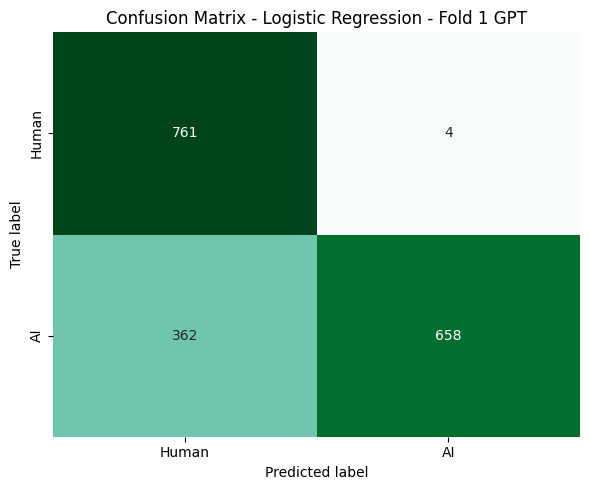


######################################################################
Example - Logistic Regression - Fold 1 GPT
######################################################################

CORRECT - class: Human (3 example)

[1] , respectiv G . 3 5 3 Analizând dinamica textuală a manualelor școlare analizate și folosind metodele descrise anterior, abordarea propusă a condus la următoarele concluzii: • Grupul de complexitate mediu al textului scade dacă verbele sunt eliminate complet; • Scăderea este treptată dacă verbele su...

[2] care participantul analizează subiectul, sub forma unei pauze de retragere a unor cuvinte, pauză intenționată sau planificată. Pe lângă pauzele din cadrul conversației putem preciza și cuvintele mai puțin importante, cele irelevante cum ar fi: abrevieri, simboluri. Aceste cuvinte pot să inducă parti...

[3] O pondere mai redusă a respondenților intervevați acum cinci ani declarau că se informează legat de viața de zi cu zi prin intermediul presei scrise (23%) 

In [11]:
y_pred_lr = evaluate_and_report(logreg_model, "Logistic Regression - Fold 1 GPT", X_val_tfidf, y_val, val_texts)
record_results("Logistic Regression - Fold 1 GPT", y_val, y_pred_lr)

In [12]:
#model download

export_classic_model(logreg_model, "logreg_model_Fold1GPT.joblib")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_Fold1GPT.joblib")

from google.colab import files
shutil.make_archive("Fold1GPT-logreg-model", "zip", ".", "logreg_model_Fold1GPT.joblib")
files.download("logreg_model_Fold1GPT.joblib")
files.download("tfidf_vectorizer_Fold1GPT.joblib")

Model saved: logreg_model_Fold1GPT.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Bi-LSTM**

In [13]:
VOCAB_SIZE = 20000
MAX_LEN = 512
EMBEDDING_DIM = 128

lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
lstm_tokenizer.fit_on_texts(train_texts)

train_sequences = lstm_tokenizer.texts_to_sequences(train_texts)
val_sequences = lstm_tokenizer.texts_to_sequences(val_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", train_padded.shape)
print("Val padded shape:", val_padded.shape)

Train padded shape: (4335, 512)
Val padded shape: (1785, 512)


In [14]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = bilstm_model.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.8323 - loss: 0.3693 - val_accuracy: 0.6039 - val_loss: 1.0696
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9871 - loss: 0.0498 - val_accuracy: 0.6252 - val_loss: 1.3876
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9866 - loss: 0.0543 - val_accuracy: 0.6303 - val_loss: 1.4490
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9848 - loss: 0.0512 - val_accuracy: 0.6090 - val_loss: 1.9589


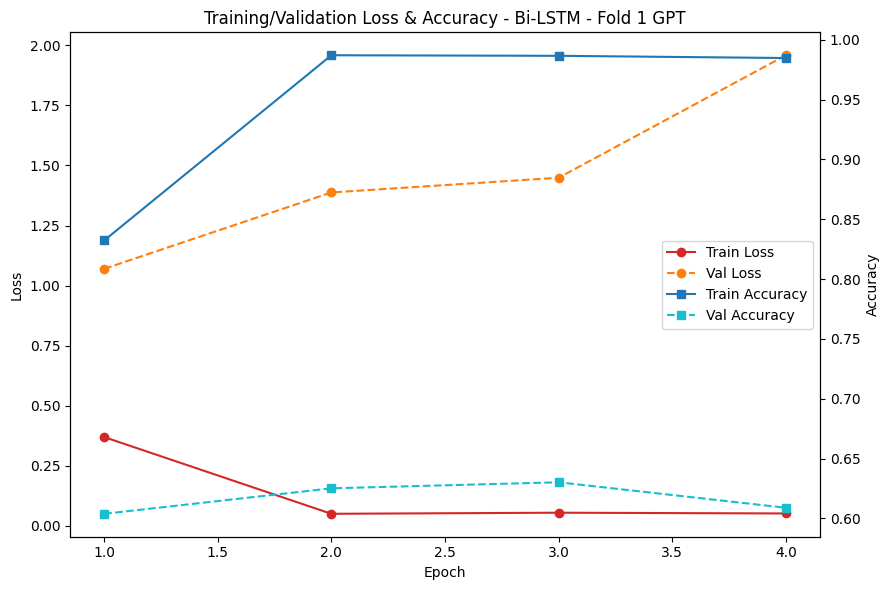

In [16]:
hist = history_lstm.history
epochs_range = range(1, len(hist["loss"]) + 1)

plot_dual_curve(
    list(epochs_range), hist["loss"], hist["val_loss"], hist["accuracy"], hist["val_accuracy"],
    x_label="Epoch", model_name="Bi-LSTM - Fold 1 GPT"
)

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
              precision    recall  f1-score   support

       Human     0.5209    0.9438    0.6713       765
          AI     0.8922    0.3490    0.5018      1020

    accuracy                         0.6039      1785
   macro avg     0.7066    0.6464    0.5865      1785
weighted avg     0.7331    0.6039    0.5744      1785



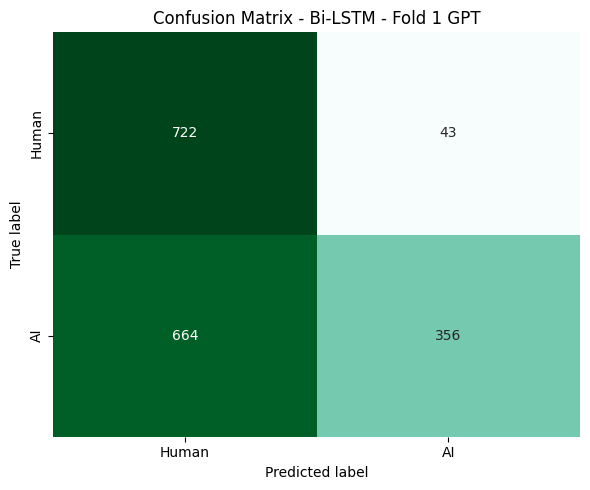


######################################################################
Example - Bi-LSTM - Fold 1 GPT
######################################################################

CORRECT - class: Human (3 example)

[1] , respectiv G . 3 5 3 Analizând dinamica textuală a manualelor școlare analizate și folosind metodele descrise anterior, abordarea propusă a condus la următoarele concluzii: • Grupul de complexitate mediu al textului scade dacă verbele sunt eliminate complet; • Scăderea este treptată dacă verbele su...

[2] care participantul analizează subiectul, sub forma unei pauze de retragere a unor cuvinte, pauză intenționată sau planificată. Pe lângă pauzele din cadrul conversației putem preciza și cuvintele mai puțin importante, cele irelevante cum ar fi: abrevieri, simboluri. Aceste cuvinte pot să inducă parti...

[3] O pondere mai redusă a respondenților intervevați acum cinci ani declarau că se informează legat de viața de zi cu zi prin intermediul presei scrise (23%) sau a radiou

In [17]:
y_pred_lstm = evaluate_and_report(bilstm_model, "Bi-LSTM - Fold 1 GPT", val_padded, y_val, val_texts, is_keras=True)
record_results("Bi-LSTM - Fold 1 GPT", y_val, y_pred_lstm)

In [18]:
#model download

bilstm_model.save("bilstm_model_Fold1GPT.keras")

with open("lstm_tokenizer_Fold1GPT.pickle", "wb") as f:
    pickle.dump(lstm_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

from google.colab import files
files.download("bilstm_model_Fold1GPT.keras")
files.download("lstm_tokenizer_Fold1GPT.pickle")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **FOLD 2 - CLAUDE**

In [19]:
import json

with open("train_CLAUDE.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_CLAUDE.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [20]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [21]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label  \
0  S-a dezvoltat o platformă pentru vizualizarea ...      1   
1  timp real. prin selecționarea datelor efective...      0   
2  Prin urmare, este esențial ca noile tehnologii...      1   
3  Analizând diversele aplicații mobile dedicate ...      1   
4  dacă distanța Levenshtein obținută este mai mi...      0   

                 AI_used  chunk_no  source  \
0            gpt-4-turbo         7     107   
1                   none        16      39   
2            gpt-4-turbo         8     127   
3  gemini-3.5-flash-lite         4     189   
4                   none         7      63   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2011  
1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2009  
2  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2011  
3  https://rochi.

In [22]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
classes = np.unique(y_train)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)

Train TF-IDF shape: (4335, 20000)
Val TF-IDF shape: (1785, 20000)


## **Logistic Regression**

[Logistic Regression - Fold 2 CLAUDE] Early stopping at epoch 6 (val loss has not improved for 5 epochs)


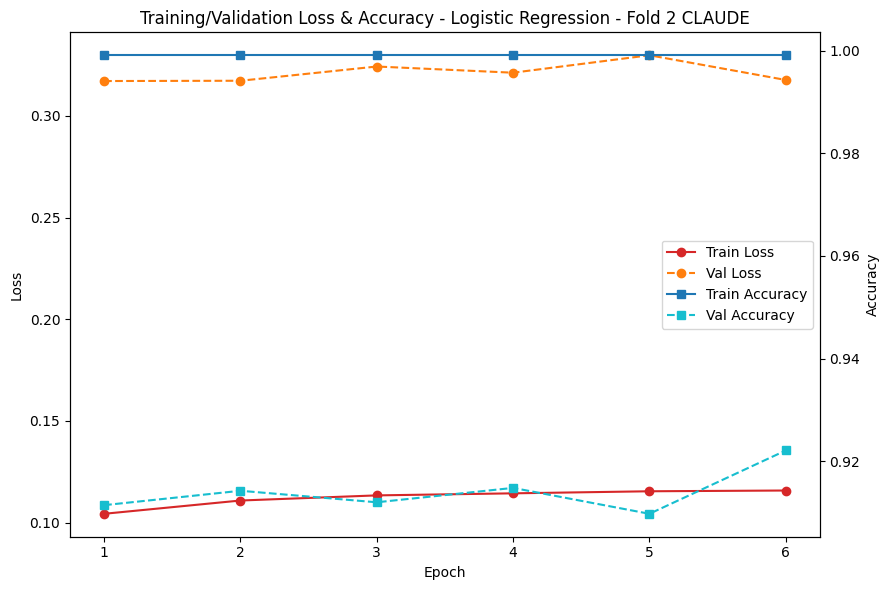

In [23]:
indices = np.arange(X_train_tfidf.shape[0])

def logreg_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

logreg_model, lr_train_losses, lr_val_losses, lr_train_accs, lr_val_accs = train_with_early_stopping(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=logreg_log_loss, max_epochs=100, patience=5, model_name="Logistic Regression - Fold 2 CLAUDE"
)

plot_dual_curve(range(1, len(lr_train_losses) + 1), lr_train_losses, lr_val_losses,
                lr_train_accs, lr_val_accs, x_label="Epoch", model_name="Logistic Regression - Fold 2 CLAUDE")

              precision    recall  f1-score   support

       Human     0.8384    0.9830    0.9049       765
          AI     0.9854    0.8578    0.9172      1020

    accuracy                         0.9115      1785
   macro avg     0.9119    0.9204    0.9111      1785
weighted avg     0.9224    0.9115    0.9119      1785



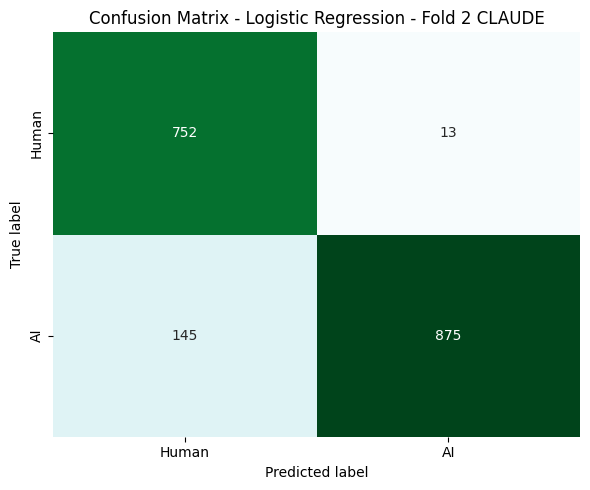


######################################################################
Example - Logistic Regression - Fold 2 CLAUDE
######################################################################

CORRECT - class: Human (3 example)

[1] • obiectele de învățare - suport al conceptelor. Obiectele de învățare (learning object) sunt văzute de standardele IMS ca resurse reproductibile și adresabile, digitale sau non-digitale, utilizate pentru a realiza activități de învățare sau activități suport. Cu ajutorul acestora se poate personali...

[2] A doua mare provocare o constituie optimizarea costurilor atașate dezvoltǎrii unor sisteme de procesare a limbajului, costuri, de multe ori, mari. În ultimii 7 ani, echipele de cercetare multidisciplinare s-au focalizat pe crearea de resurse lingvistice scrise și acustice, pe portarea tehnologiilor,...

[3] Discriminarea limbilor pe baza n-gramelor pleacă de la observația că pentru fiecare limbă anumite n-grame apar mai frecvent decât altele. Studii experim

In [24]:
y_pred_lr = evaluate_and_report(logreg_model, "Logistic Regression - Fold 2 CLAUDE", X_val_tfidf, y_val, val_texts)
record_results("Logistic Regression - Fold 2 CLAUDE", y_val, y_pred_lr)

In [25]:
#model download

export_classic_model(logreg_model, "logreg_model_Fold2CLAUDE.joblib")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_Fold2CLAUDE.joblib")

from google.colab import files
shutil.make_archive("Fold2CLAUDE-logreg-model", "zip", ".", "logreg_model_Fold2CLAUDE.joblib")
files.download("logreg_model_Fold2CLAUDE.joblib")
files.download("tfidf_vectorizer_Fold2CLAUDE.joblib")

Model saved: logreg_model_Fold2CLAUDE.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Bi-LSTM**

In [26]:
VOCAB_SIZE = 20000
MAX_LEN = 512
EMBEDDING_DIM = 128

lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
lstm_tokenizer.fit_on_texts(train_texts)

train_sequences = lstm_tokenizer.texts_to_sequences(train_texts)
val_sequences = lstm_tokenizer.texts_to_sequences(val_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", train_padded.shape)
print("Val padded shape:", val_padded.shape)

Train padded shape: (4335, 512)
Val padded shape: (1785, 512)


In [27]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = bilstm_model.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7949 - loss: 0.4092 - val_accuracy: 0.8129 - val_loss: 0.4228
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9629 - loss: 0.1201 - val_accuracy: 0.8521 - val_loss: 0.4367
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9912 - loss: 0.0278 - val_accuracy: 0.8118 - val_loss: 0.6988
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9972 - loss: 0.0107 - val_accuracy: 0.8420 - val_loss: 0.6836


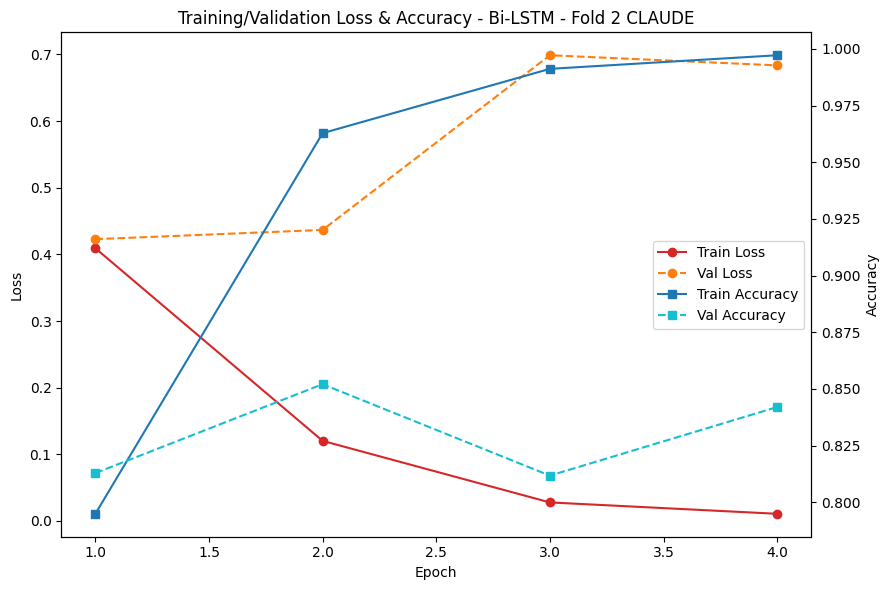

In [29]:
hist = history_lstm.history
epochs_range = range(1, len(hist["loss"]) + 1)

plot_dual_curve(
    list(epochs_range), hist["loss"], hist["val_loss"], hist["accuracy"], hist["val_accuracy"],
    x_label="Epoch", model_name="Bi-LSTM - Fold 2 CLAUDE"
)

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
              precision    recall  f1-score   support

       Human     0.7924    0.7634    0.7776       765
          AI     0.8273    0.8500    0.8385      1020

    accuracy                         0.8129      1785
   macro avg     0.8098    0.8067    0.8081      1785
weighted avg     0.8123    0.8129    0.8124      1785



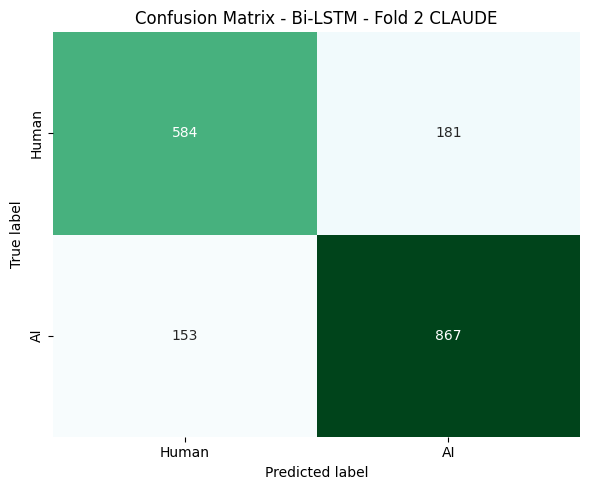


######################################################################
Example - Bi-LSTM - Fold 2 CLAUDE
######################################################################

CORRECT - class: Human (3 example)

[1] • obiectele de învățare - suport al conceptelor. Obiectele de învățare (learning object) sunt văzute de standardele IMS ca resurse reproductibile și adresabile, digitale sau non-digitale, utilizate pentru a realiza activități de învățare sau activități suport. Cu ajutorul acestora se poate personali...

[2] A doua mare provocare o constituie optimizarea costurilor atașate dezvoltǎrii unor sisteme de procesare a limbajului, costuri, de multe ori, mari. În ultimii 7 ani, echipele de cercetare multidisciplinare s-au focalizat pe crearea de resurse lingvistice scrise și acustice, pe portarea tehnologiilor,...

[3] Discriminarea limbilor pe baza n-gramelor pleacă de la observația că pentru fiecare limbă anumite n-grame apar mai frecvent decât altele. Studii experimentale reali

In [30]:
y_pred_lstm = evaluate_and_report(bilstm_model, "Bi-LSTM - Fold 2 CLAUDE", val_padded, y_val, val_texts, is_keras=True)
record_results("Bi-LSTM - Fold 2 CLAUDE", y_val, y_pred_lstm)

In [31]:
#model download

bilstm_model.save("bilstm_model_Fold2CLAUDE.keras")

with open("lstm_tokenizer_Fold2CLAUDE.pickle", "wb") as f:
    pickle.dump(lstm_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

from google.colab import files
files.download("bilstm_model_Fold2CLAUDE.keras")
files.download("lstm_tokenizer_Fold2CLAUDE.pickle")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **FOLD 3 - GEMINI**

In [32]:
import json

with open("train_GEMINI.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_GEMINI.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [33]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [34]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label  \
0  Tehnologiile Asistive (TA) au revoluționat mod...      1   
1  Testele au fost realizate pentru obținerea div...      0   
2  Activitatea în condiții de stres determină mod...      1   
3  Evoluția cercetărilor privind utilizabilitatea...      1   
4  ## Utilizarea WordNet pentru Recalcularea Clas...      1   

             AI_used  chunk_no  source  \
0        gpt-4-turbo        15      95   
1               none         3     154   
2  claude-sonnet-4-5         7      68   
3  claude-sonnet-4-5         9      61   
4  claude-sonnet-4-5         4      75   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2010  
1  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2012  
2  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2010  
3  https://rochi.utcluj.ro/rrioc/articole

In [35]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
classes = np.unique(y_train)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)

Train TF-IDF shape: (4335, 20000)
Val TF-IDF shape: (1785, 20000)


## **Logistic Regression**

[Logistic Regression - Fold 3 GEMINI] Early stopping at epoch 6 (val loss has not improved for 5 epochs)


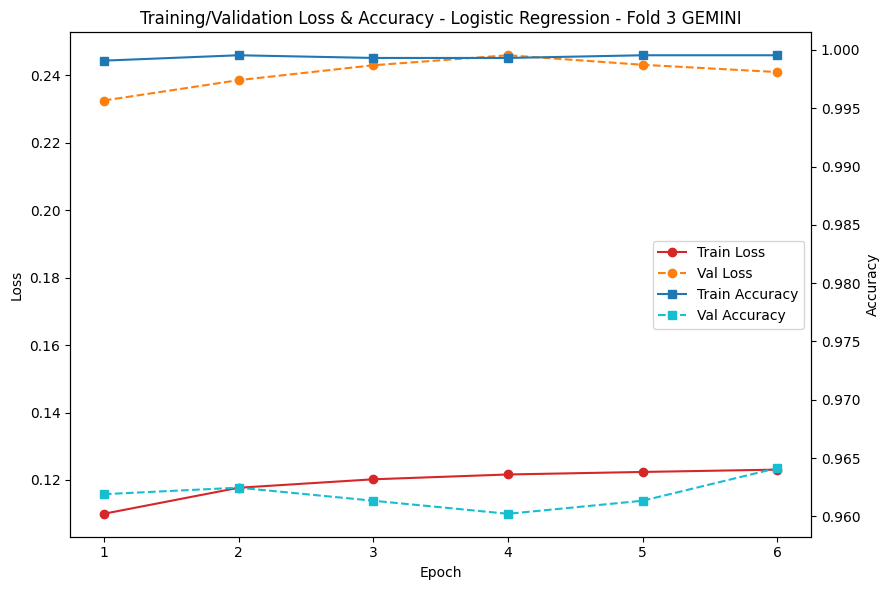

In [36]:
indices = np.arange(X_train_tfidf.shape[0])

def logreg_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

logreg_model, lr_train_losses, lr_val_losses, lr_train_accs, lr_val_accs = train_with_early_stopping(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=logreg_log_loss, max_epochs=100, patience=5, model_name="Logistic Regression - Fold 3 GEMINI"
)

plot_dual_curve(range(1, len(lr_train_losses) + 1), lr_train_losses, lr_val_losses,
                lr_train_accs, lr_val_accs, x_label="Epoch", model_name="Logistic Regression - Fold 3 GEMINI")

              precision    recall  f1-score   support

       Human     0.9214    0.9961    0.9573       765
          AI     0.9969    0.9363    0.9656      1020

    accuracy                         0.9619      1785
   macro avg     0.9591    0.9662    0.9615      1785
weighted avg     0.9645    0.9619    0.9620      1785



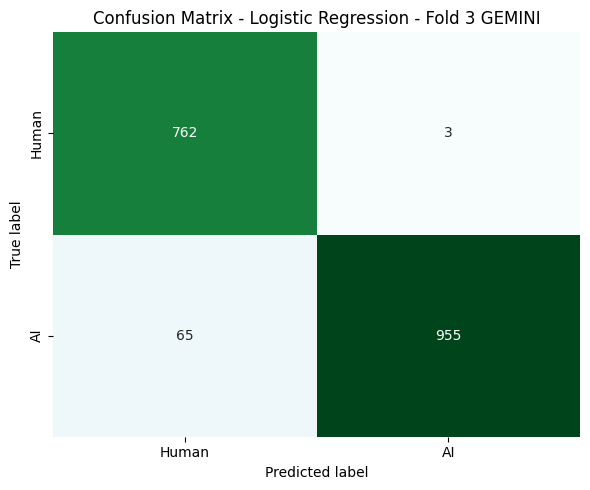


######################################################################
Example - Logistic Regression - Fold 3 GEMINI
######################################################################

CORRECT - class: Human (3 example)

[1] Această lucrare își propune să prezinte o scurtă clasificare a celor mai semnificative jocuri audio din perspectiva accesibilității, a funcționalității, a tehnicilor audio și a metodelor de interacțiune cu utilizatorul. 2. Descrierea jocurilor audio 2.1 Caracteristici generale ale jocurilor audio De...

[2] avut loc și, eventual, de către o locație. Aplicațiile practice realizate pentru recunoașterea evenimentelor sunt direcționate de regulă înspre un anumit domeniu specific. Totuși, majoritatea au fost dezvoltate pentru texte din rețele sociale, în special Twitter, și folosesc metode specifice regăsir...

[3] Serviciul de mesaje scurte este, de altfel, o „tehnologie socială” cu ajutorul căreia și cei mai retrași indivizi pot aduce în discuție subiecte dificil

In [37]:
y_pred_lr = evaluate_and_report(logreg_model, "Logistic Regression - Fold 3 GEMINI", X_val_tfidf, y_val, val_texts)
record_results("Logistic Regression - Fold 3 GEMINI", y_val, y_pred_lr)

In [38]:
#model download

export_classic_model(logreg_model, "logreg_model_Fold3GEMINI.joblib")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_Fold3GEMINI.joblib")

from google.colab import files
shutil.make_archive("Fold3GEMINI-logreg-model", "zip", ".", "logreg_model_Fold3GEMINI.joblib")
files.download("logreg_model_Fold3GEMINI.joblib")
files.download("tfidf_vectorizer_Fold3GEMINI.joblib")

Model saved: logreg_model_Fold3GEMINI.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Bi-LSTM**

In [39]:
VOCAB_SIZE = 20000
MAX_LEN = 512
EMBEDDING_DIM = 128

lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
lstm_tokenizer.fit_on_texts(train_texts)

train_sequences = lstm_tokenizer.texts_to_sequences(train_texts)
val_sequences = lstm_tokenizer.texts_to_sequences(val_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", train_padded.shape)
print("Val padded shape:", val_padded.shape)

Train padded shape: (4335, 512)
Val padded shape: (1785, 512)


In [40]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = bilstm_model.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7435 - loss: 0.5273 - val_accuracy: 0.8426 - val_loss: 0.3684
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9578 - loss: 0.1303 - val_accuracy: 0.9367 - val_loss: 0.1865
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9910 - loss: 0.0314 - val_accuracy: 0.9104 - val_loss: 0.2550
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9956 - loss: 0.0166 - val_accuracy: 0.9053 - val_loss: 0.4313
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9986 - loss: 0.0090 - val_accuracy: 0.9300 - val_loss: 0.2992


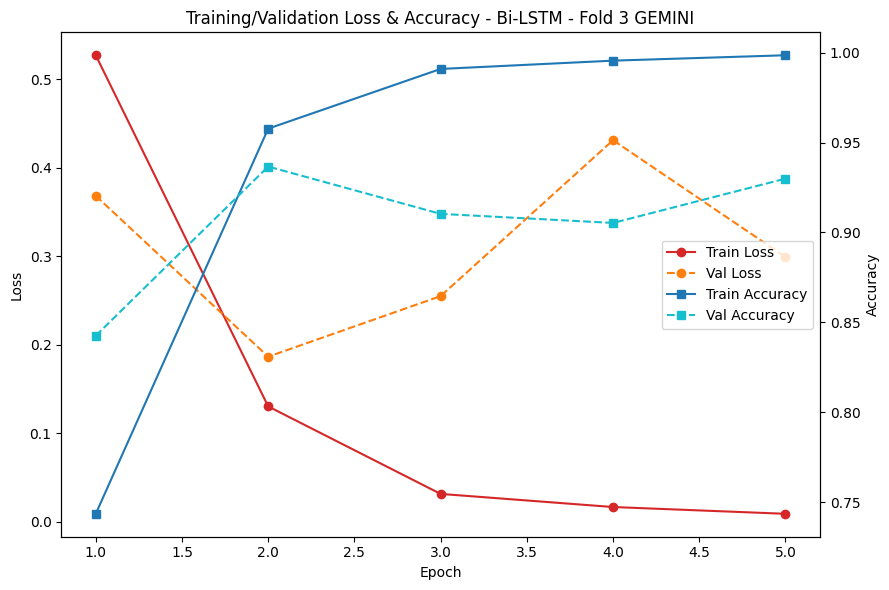

In [42]:
hist = history_lstm.history
epochs_range = range(1, len(hist["loss"]) + 1)

plot_dual_curve(
    list(epochs_range), hist["loss"], hist["val_loss"], hist["accuracy"], hist["val_accuracy"],
    x_label="Epoch", model_name="Bi-LSTM - Fold 3 GEMINI"
)

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
              precision    recall  f1-score   support

       Human     0.8976    0.9621    0.9287       765
          AI     0.9699    0.9176    0.9431      1020

    accuracy                         0.9367      1785
   macro avg     0.9338    0.9399    0.9359      1785
weighted avg     0.9389    0.9367    0.9369      1785



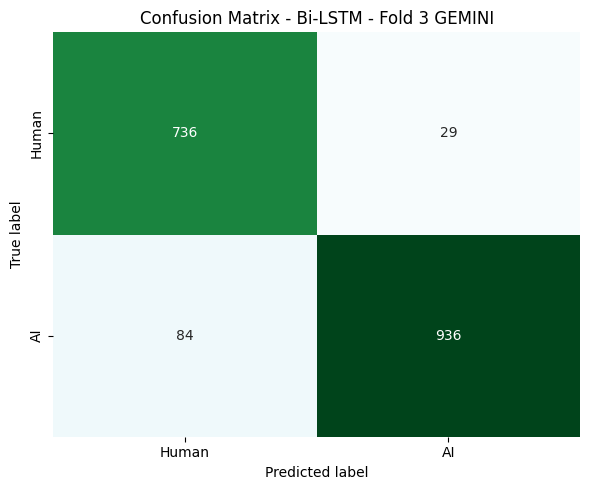


######################################################################
Example - Bi-LSTM - Fold 3 GEMINI
######################################################################

CORRECT - class: Human (3 example)

[1] Această lucrare își propune să prezinte o scurtă clasificare a celor mai semnificative jocuri audio din perspectiva accesibilității, a funcționalității, a tehnicilor audio și a metodelor de interacțiune cu utilizatorul. 2. Descrierea jocurilor audio 2.1 Caracteristici generale ale jocurilor audio De...

[2] Serviciul de mesaje scurte este, de altfel, o „tehnologie socială” cu ajutorul căreia și cei mai retrași indivizi pot aduce în discuție subiecte dificile. Un studiu realizat pe 532 de subiecți, studenți (Leung, 2007), subliniază rolurile pozitive al SMS-urilor, identificate de subiecți – înfrângerea...

[3] 3.1. Specificul limbii române La nivel sintactic limba românǎ se individualizeazǎ în cadrul limbilor romanice prin: nelexicalizarea subiectului prenominal, dublarea

In [43]:
y_pred_lstm = evaluate_and_report(bilstm_model, "Bi-LSTM - Fold 3 GEMINI", val_padded, y_val, val_texts, is_keras=True)
record_results("Bi-LSTM - Fold 3 GEMINI", y_val, y_pred_lstm)

In [44]:
#model download

bilstm_model.save("bilstm_model_Fold3GEMINI.keras")

with open("lstm_tokenizer_Fold3GEMINI.pickle", "wb") as f:
    pickle.dump(lstm_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

from google.colab import files
files.download("bilstm_model_Fold3GEMINI.keras")
files.download("lstm_tokenizer_Fold3GEMINI.pickle")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>